# Feed Recommendation System
Using PCA and cosine similarity to suggest similar chicken feeds based on Chickwts.

## Load libraries and data

In [2]:
# import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files
uploaded = files.upload()

Saving chickwts.csv to chickwts.csv


In [3]:
# load the chickwts dataset
chickwts_df = pd.read_csv('chickwts.csv')
chickwts_df.head()

,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


Each row is one chicken with its weight and the feed type it was given.

## Check the data

In [4]:
# check for missing values and duplicate rows
print(chickwts_df.isnull().sum())
print('Duplicate rows:', chickwts_df.duplicated().sum())

weight    0
feed      0
dtype: int64
Duplicate rows: 1


No missing values. There is one duplicate row but it is a real coincidence, two chickens with the same weight and feed, so we leave it in.

## Build a profile for each feed type

In [5]:
# group by feed and get the average weight, spread, and sample size
feed_profiles = chickwts_df.groupby('feed')['weight'].agg(mean_weight='mean', std_weight='std', sample_size='count').sort_index()
feed_profiles

,mean_weight,std_weight,sample_size
feed,,,
casein,323.583333,64.433840,12
horsebean,160.200000,38.625841,10
linseed,218.750000,52.235698,12
meatmeal,276.909091,64.900623,11
soybean,246.428571,54.129068,14
sunflower,328.916667,48.836384,12


Sunflower has the highest average weight and horsebean has the lowest.

## Standardize the weight feature

In [6]:
# scale the mean weight so all feeds are on the same footing
scaler = StandardScaler()
feed_scaled = scaler.fit_transform(feed_profiles[['mean_weight']])

## Reduce to one principal component

In [7]:
# apply PCA to compress the scaled weight into one component
pca = PCA(n_components=1)
feed_components = pca.fit_transform(feed_scaled)
print('Variance retained:', pca.explained_variance_ratio_.sum())

Variance retained: 1.0


Since we only had one feature to begin with, PCA keeps all of it, it just does not reduce anything here.

## Compute cosine similarity between feeds

In [8]:
# compare every feed to every other feed using cosine similarity
feed_similarity = pd.DataFrame(cosine_similarity(feed_components), index=feed_profiles.index, columns=feed_profiles.index)
feed_similarity.round(2)

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


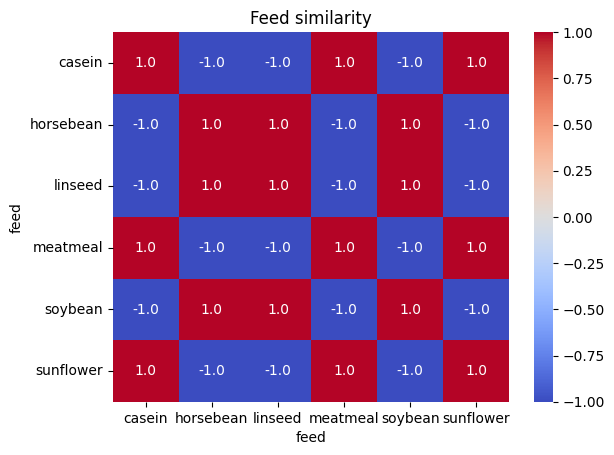

In [9]:
# visualize the similarity scores as a heatmap
sns.heatmap(feed_similarity, annot=True, fmt='.1f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feed similarity')
plt.show()

Feeds with heavier chickens on average score close to 1 with each other, and close to -1 with feeds that produced lighter chickens.

## Build the recommendation function

In [10]:
# return the most similar feeds to a given feed, using weight difference to break ties
def recommend_feed(feed_name, num_recommendations=3):
    feed_name = feed_name.strip().lower()
    alternatives = feed_profiles.drop(index=feed_name).copy()
    alternatives['cosine_similarity'] = feed_similarity.loc[feed_name, alternatives.index]
    alternatives['weight_difference'] = abs(alternatives['mean_weight'] - feed_profiles.loc[feed_name, 'mean_weight'])
    return alternatives.sort_values(['cosine_similarity', 'weight_difference'], ascending=[False, True]).head(num_recommendations)

## Try it out

In [11]:
# get the top 3 recommended feeds for soybean
recommend_feed('soybean')

,mean_weight,std_weight,sample_size,cosine_similarity,weight_difference
feed,,,,,
linseed,218.750000,52.235698,12,1.0,27.678571
horsebean,160.200000,38.625841,10,1.0,86.228571
meatmeal,276.909091,64.900623,11,-1.0,30.480519


Linseed comes back first since it is closest in weight among the top scoring feeds.

In [12]:
# get the top recommendation for every feed at once
pd.DataFrame([{'feed': feed, 'top_recommendation': recommend_feed(feed, 1).index[0]} for feed in feed_profiles.index])

,feed,top_recommendation
0,casein,sunflower
1,horsebean,linseed
2,linseed,soybean
3,meatmeal,casein
4,soybean,linseed
5,sunflower,casein


## Conclusion
The recommender groups feeds by how similar their average chicken weight is. It is a simple descriptive tool, not proof that any feed works better than another.